# Analyze Scheduler Output
Generates AP status summaries, monthly system flow, and BTG control charts from `output/scheduler_trace_output.xlsx`.

## 1. Imports and Paths
Configure the exported scheduler workbook, analysis window, and chart output path.

In [8]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

In [9]:
CODECELL_OUTPUT = True

rootpath = Path.cwd()
EXPORT_PATH = rootpath / 'output'
trace_file = EXPORT_PATH / 'scheduler_trace_output.xlsx'
chart_output_path = EXPORT_PATH / 'monthly_btg_control_charts.png'

# Monthly system-flow window.
plot_start = pd.Timestamp('2024-06-01')
plot_end = pd.Timestamp('2026-04-30')

# Choose any subset from: ['total', 'structure', 'systems', 'declam', 'test']
SELECTED_TEAMS = ['total', 'structure', 'systems', 'declam', 'test']

# Rolling view size in months. Set to None to show all available months unless explicit bounds are provided.
CONTROL_WINDOW_MONTHS = 36

# Optional hard-coded month bounds; use 'YYYY-MM' or 'YYYY-MM-01'.
CONTROL_START_MONTH = None
CONTROL_END_MONTH = None

## 2. Load Scheduler Trace Workbook
Read the trace workbook sheets used by the summaries and charts.

In [10]:
required_sheets = [
    'ChickenTracks',
    'Daily AP Status',
    'Exit Summary',
    'Active AP Status',
    'BTG structure',
    'BTG systems',
    'BTG declam',
    'BTG test',
]

if not trace_file.exists():
    raise FileNotFoundError(f'Missing scheduler trace workbook: {trace_file}')

workbook = pd.ExcelFile(trace_file)
missing_sheets = [sheet for sheet in required_sheets if sheet not in workbook.sheet_names]
if missing_sheets:
    raise ValueError(f'Missing required sheet(s) in {trace_file}: {missing_sheets}')

chickentracks_df = pd.read_excel(trace_file, sheet_name='ChickenTracks')
daily_status_df = pd.read_excel(trace_file, sheet_name='Daily AP Status')
delivery_df = pd.read_excel(trace_file, sheet_name='Exit Summary')
active_status_df = pd.read_excel(trace_file, sheet_name='Active AP Status')

for df in [chickentracks_df, daily_status_df, delivery_df]:
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce').dt.normalize()

if 'Actual_Exit_Date' in delivery_df.columns:
    delivery_df['Actual_Exit_Date'] = pd.to_datetime(delivery_df['Actual_Exit_Date'], errors='coerce').dt.normalize()

if CODECELL_OUTPUT:
    print(f'Loaded scheduler trace workbook: {trace_file}')
    print('Workbook sheets:', workbook.sheet_names)

Loaded scheduler trace workbook: /Users/jishnughosh/Documents/GitHub/BSC-FGI_Scheduler/output/scheduler_trace_output.xlsx
Workbook sheets: ['ChickenTracks', 'Labor Allocation', 'Moves Per Day', 'Daily AP Status', 'Exit Summary', 'Active AP Status', 'KPI Summary', 'Team KPIs', 'BTG structure', 'BTG systems', 'BTG declam', 'BTG test']


## 3. Daily AP Status Summary
Summarize the latest daily AP status snapshot and display the exported active AP status table.

In [11]:
btg_cols = ['FGI_tot', 'structure', 'systems', 'declam', 'test']

daily_ap_status_summary = pd.DataFrame()
latest_daily_ap_status = pd.DataFrame()
location_summary = pd.DataFrame()

if daily_status_df.empty:
    print('Daily AP Status is empty.')
else:
    status = daily_status_df.copy()
    status['Date'] = pd.to_datetime(status['Date'], errors='coerce').dt.normalize()
    status = status.dropna(subset=['Date'])

    for col in btg_cols:
        if col in status.columns:
            status[col] = pd.to_numeric(status[col], errors='coerce').fillna(0)

    latest_status_date = status['Date'].max()
    latest_daily_ap_status = (
        status[status['Date'] == latest_status_date]
        .sort_values(['Location', 'LN'])
        .reset_index(drop=True)
    )

    summary_rows = [
        {'Metric': 'Status date', 'Value': latest_status_date.date()},
        {'Metric': 'Active AP count', 'Value': latest_daily_ap_status['LN'].nunique()},
        {'Metric': 'Move required count', 'Value': int(latest_daily_ap_status.get('moveReq', pd.Series(dtype=bool)).fillna(False).sum())},
    ]

    for col in btg_cols:
        if col in latest_daily_ap_status.columns:
            summary_rows.append({'Metric': f'Remaining {col}', 'Value': latest_daily_ap_status[col].sum()})

    daily_ap_status_summary = pd.DataFrame(summary_rows)

    location_summary = (
        latest_daily_ap_status
        .groupby('Location', dropna=False)
        .agg(
            AP_Count=('LN', 'nunique'),
            Move_Required=('moveReq', 'sum'),
            Remaining_FGI_Tot=('FGI_tot', 'sum'),
            Remaining_Structure=('structure', 'sum'),
            Remaining_Systems=('systems', 'sum'),
            Remaining_Declam=('declam', 'sum'),
            Remaining_Test=('test', 'sum'),
        )
        .reset_index()
        .sort_values(['AP_Count', 'Location'], ascending=[False, True])
    )

    display(daily_ap_status_summary)
    display(location_summary)

if not active_status_df.empty:
    display(active_status_df.sort_values('LN').reset_index(drop=True))

,Metric,Value
0,Status date,2027-03-10
1,Active AP count,20
2,Move required count,1
3,Remaining FGI_tot,1703
4,Remaining structure,0.0
5,Remaining systems,0.0
6,Remaining declam,0.0
7,Remaining test,0.0


,Location,AP_Count,Move_Required,Remaining_FGI_Tot,Remaining_Structure,Remaining_Systems,Remaining_Declam,Remaining_Test
0,BSC1,1,1,109,0.0,0.0,0.0,0.0
1,C2,1,0,89,0.0,0.0,0.0,0.0
2,C3,1,0,82,0.0,0.0,0.0,0.0
3,C4,1,0,102,0.0,0.0,0.0,0.0
4,C5,1,0,78,0.0,0.0,0.0,0.0
5,CR1,1,0,79,0.0,0.0,0.0,0.0
6,CR2,1,0,46,0.0,0.0,0.0,0.0
7,CR3,1,0,117,0.0,0.0,0.0,0.0
8,FGI1,1,0,84,0.0,0.0,0.0,0.0
9,FGI2,1,0,95,0.0,0.0,0.0,0.0


,LN,Location,Task_State,Move_Req,Destination,Queues,Queue_Count,FGI_structure,FGI_systems,FGI_declam,FGI_test,Compass_Complete,Paint_Complete
0,73,CR2,btg_completion,False,NaN,FGI task:paint,1,0,0,0,0,True,False
1,75,CR3,compass,False,NaN,FGI task:compass,1,0,0,0,0,False,True
2,76,P3SW,btg_completion,False,NaN,FGI task:compass,1,0,0,0,0,False,True
3,77,P3E,btg_completion,False,NaN,FGI task:compass,1,0,0,0,0,False,True
4,78,P3W,btg_completion,False,NaN,FGI task:compass,1,0,0,0,0,False,True
5,79,S1,btg_completion,False,NaN,FGI task:compass,1,0,0,0,0,False,True
6,80,S2,btg_completion,False,NaN,FGI task:compass,1,0,0,0,0,False,True
7,81,FGI1,btg_completion,False,NaN,FGI task:compass,1,0,0,0,0,False,True
8,82,S3,btg_completion,False,NaN,FGI task:compass,1,0,0,0,0,False,True
9,83,FGI2,btg_completion,False,NaN,FGI task:compass,1,0,0,0,0,False,True


## 4. Monthly System Flow
Plot monthly rollouts, monthly exits, and APs in system using only `scheduler_trace_output.xlsx`.

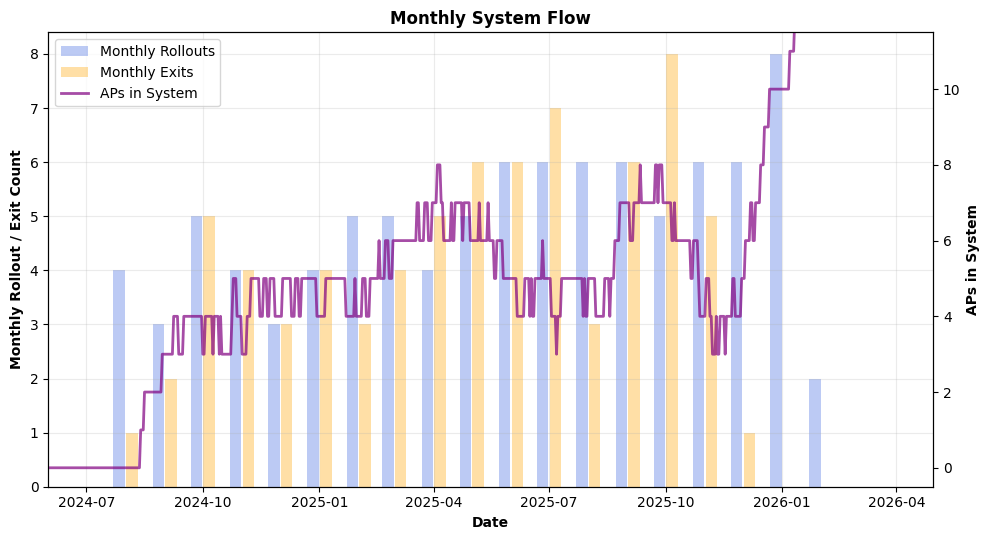

In [12]:
plot_months = pd.date_range(plot_start, plot_end, freq='MS')
plot_days = pd.date_range(plot_start, plot_end, freq='D')

if daily_status_df.empty:
    monthly_rollouts = pd.Series(0, index=plot_months, dtype='int64')
    aps_in_system = pd.Series(0, index=plot_days, dtype='int64')
else:
    status = daily_status_df.copy()
    status['Date'] = pd.to_datetime(status['Date'], errors='coerce').dt.normalize()
    status = status.dropna(subset=['Date'])

    first_seen_dates = status.groupby('LN')['Date'].min()
    monthly_rollouts = (
        first_seen_dates
        .dt.to_period('M')
        .dt.to_timestamp()
        .value_counts()
        .sort_index()
        .reindex(plot_months, fill_value=0)
    )

    aps_in_system = (
        status
        .groupby('Date')['LN']
        .nunique()
        .sort_index()
        .reindex(plot_days, fill_value=0)
    )

if len(delivery_df) > 0 and 'Actual_Exit_Date' in delivery_df.columns:
    exit_dates = pd.to_datetime(delivery_df['Actual_Exit_Date'], errors='coerce').dropna().dt.normalize()
    monthly_exits = (
        exit_dates
        .dt.to_period('M')
        .dt.to_timestamp()
        .value_counts()
        .sort_index()
        .reindex(plot_months, fill_value=0)
    )
else:
    monthly_exits = pd.Series(0, index=plot_months, dtype='int64')

fig, ax1 = plt.subplots(figsize=(10, 5.5))

ax1.bar(plot_months - pd.Timedelta(days=5), monthly_rollouts, width=9, color='royalblue', alpha=0.35, label='Monthly Rollouts')
ax1.bar(plot_months + pd.Timedelta(days=5), monthly_exits, width=9, color='orange', alpha=0.35, label='Monthly Exits')

ax1.set_title('Monthly System Flow', fontweight='bold')
ax1.set_xlabel('Date', fontweight='bold')
ax1.set_ylabel('Monthly Rollout / Exit Count', fontweight='bold')
ax1.set_xlim(plot_start, plot_end)
ax1.set_ylim(0, 8.4)
ax1.set_yticks(range(0, 9, 1))
ax1.grid(True, alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(aps_in_system.index, aps_in_system, color='purple', alpha=0.7, linewidth=2, label='APs in System')
ax2.set_ylabel('APs in System', fontweight='bold')
ax2.set_ylim(-0.5, 11.5)
ax2.set_yticks(range(0, 11, 2))

ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

fig.tight_layout()
plt.show()

## 5. Monthly Control Charts
Build monthly completed and remaining BTG control charts from the exported BTG and Daily AP Status sheets.

In [13]:
def control_chart(SELECTED_TEAMS=SELECTED_TEAMS, CONTROL_WINDOW_MONTHS=CONTROL_WINDOW_MONTHS, CONTROL_START_MONTH=CONTROL_START_MONTH, CONTROL_END_MONTH=CONTROL_END_MONTH):
    btg_sheet_map = {
        'structure': 'BTG structure',
        'systems': 'BTG systems',
        'declam': 'BTG declam',
        'test': 'BTG test'
    }
    remaining_col_map = {
        'total': 'FGI_tot',
        'structure': 'structure',
        'systems': 'systems',
        'declam': 'declam',
        'test': 'test'
    }

    def _monthly_completion_from_sheet(workbook_path, sheet_name):
        df = pd.read_excel(workbook_path, sheet_name=sheet_name)

        if len(df.columns) == 0:
            return pd.Series(dtype=float)

        date_col = 'Date' if 'Date' in df.columns else df.columns[0]
        df = df.copy()
        df[date_col] = pd.to_datetime(df[date_col], errors='coerce').dt.normalize()
        df = df[df[date_col].notna()].reset_index(drop=True)

        value_cols = [col for col in df.columns if col != date_col]
        if len(value_cols) == 0:
            return pd.Series(dtype=float)

        daily = (
            df.groupby(date_col)[value_cols]
            .sum(numeric_only=True)
            .sum(axis=1)
            .sort_index()
        )

        monthly = daily.groupby(pd.Grouper(freq='MS')).sum(min_count=1).fillna(0)
        monthly.index.name = 'Month'
        return monthly

    def _monthly_remaining_from_sheet(workbook_path, sheet_name, value_col):
        df = pd.read_excel(workbook_path, sheet_name=sheet_name)

        if 'Date' not in df.columns or value_col not in df.columns:
            return pd.Series(dtype=float)

        df = df.copy()
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce').dt.normalize()
        df[value_col] = pd.to_numeric(df[value_col], errors='coerce')
        df = df[df['Date'].notna()].reset_index(drop=True)

        daily = df.groupby('Date')[value_col].sum(min_count=1).sort_index()
        monthly = daily.groupby(pd.Grouper(freq='MS')).last()
        monthly.index.name = 'Month'
        return monthly

    def _month_floor(value):
        return pd.Timestamp(value).to_period('M').to_timestamp()

    def _filter_month_window(series, months=None, start_month=None, end_month=None):
        if series is None or len(series) == 0:
            return series

        s = series.sort_index().copy()

        if start_month is not None or end_month is not None:
            start = _month_floor(start_month) if start_month is not None else s.index.min()
            end = _month_floor(end_month) if end_month is not None else s.index.max()
        elif months is not None and months > 0:
            end = s.index.max()
            start = (end - pd.DateOffset(months=months - 1)).to_period('M').to_timestamp()
        else:
            start = s.index.min()
            end = s.index.max()

        if start > end:
            start, end = end, start

        return s[(s.index >= start) & (s.index <= end)]

    def _control_limits(series):
        clean = series.dropna().astype(float)
        if clean.empty:
            return np.nan, np.nan, np.nan

        mean = clean.mean()
        std = clean.std(ddof=0)
        ucl = mean + (2 * std)
        lcl = max(mean - (2 * std), 0)
        return mean, ucl, lcl

    def _shared_axis_limits(*series_list):
        y_values = []
        date_values = []

        for series in series_list:
            if series is None or len(series) == 0:
                continue

            clean = series.dropna().astype(float)
            if clean.empty:
                continue

            y_values.extend(clean.tolist())
            date_values.extend(clean.index.tolist())

            mean, ucl, lcl = _control_limits(clean)
            for value in [mean, ucl, lcl]:
                if pd.notna(value):
                    y_values.append(value)

        if len(y_values) == 0:
            y_limit = (0, 1)
        else:
            y_max = max(max(y_values), 1)

            if y_max <= 10:
                step = 1
            elif y_max <= 50:
                step = 5
            elif y_max <= 200:
                step = 25
            else:
                step = 50

            y_limit = (0, np.ceil((y_max * 1.08) / step) * step)

        if len(date_values) == 0:
            x_limit = None
        else:
            start = min(date_values) - pd.DateOffset(days=15)
            end = max(date_values) + pd.DateOffset(days=15)
            x_limit = (start, end)

        return y_limit, x_limit

    def _month_tick_interval(x_limit):
        if x_limit is None:
            return 1

        start = pd.Timestamp(x_limit[0])
        end = pd.Timestamp(x_limit[1])
        month_count = max(1, ((end.year - start.year) * 12) + end.month - start.month + 1)
        return max(1, int(np.ceil(month_count / 6)))

    def _plot_control_chart(ax, series, chart_name, ylabel, line_label, y_limit=None, x_limit=None, line_color='#0070C0'):
        series = series.dropna().astype(float)

        ax.set_title(f'Control Chart: {chart_name} vs. Dates\nUCL/LCL at Mean +/- 2 sigma', fontsize=13, fontweight='bold', pad=16)
        ax.set_ylabel(ylabel, fontsize=10, fontweight='bold')
        ax.set_xlabel('Date', fontsize=10, fontweight='bold')
        ax.grid(True, axis='both', color='#D9D9D9', alpha=0.5)
        ax.set_axisbelow(True)

        for spine in ax.spines.values():
            spine.set_color('black')
            spine.set_linewidth(0.8)

        if y_limit is not None:
            ax.set_ylim(y_limit)

        if x_limit is not None:
            ax.set_xlim(x_limit)

        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=_month_tick_interval(x_limit)))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax.tick_params(axis='x', rotation=45)

        if series.empty:
            ax.text(0.5, 0.5, 'No data available for selected window', ha='center', va='center', transform=ax.transAxes)
            return

        mean, ucl, lcl = _control_limits(series)
        ax.plot(series.index, series.values, color=line_color, marker='o', markersize=2.5, linewidth=1.0, label=line_label, zorder=3)
        ax.axhline(mean, color='green', linestyle='--', linewidth=1.3, label=f'Mean ({mean:.1f})', zorder=2)
        ax.axhline(ucl, color='red', linestyle='-', linewidth=1.3, label=f'UCL ({ucl:.1f}) - Add Vertical Day', zorder=2)
        ax.axhline(lcl, color='orange', linestyle='-', linewidth=1.3, label=f'LCL ({lcl:.1f}) - Can Add New LN', zorder=2)
        ax.axhspan(0, lcl, color='#FFD966', alpha=0.25, label='Available Capacity Zone', zorder=0)

        ax.legend(fontsize=8, loc='upper left', frameon=True)

    valid_teams = list(remaining_col_map.keys())
    selected_teams = [team for team in SELECTED_TEAMS if team in valid_teams]
    if len(selected_teams) == 0:
        raise ValueError(f'No valid teams selected. Choose from: {valid_teams}')

    monthly_completion = {
        team: _monthly_completion_from_sheet(trace_file, btg_sheet_map[team])
        for team in ['structure', 'systems', 'declam', 'test']
    }
    monthly_completion['total'] = pd.concat(monthly_completion.values(), axis=1).fillna(0).sum(axis=1)

    monthly_remaining = {
        team: _monthly_remaining_from_sheet(trace_file, 'Daily AP Status', column)
        for team, column in remaining_col_map.items()
    }

    chart_specs = [
        (team_key, f'{team_key.capitalize() if team_key != "total" else "Total"} BTG')
        for team_key in selected_teams
    ]

    fig, axes = plt.subplots(len(chart_specs), 2, figsize=(18, max(6 * len(chart_specs), 8)), constrained_layout=True, squeeze=False)
    fig.patch.set_facecolor('white')
    fig.patch.set_edgecolor('black')
    fig.patch.set_linewidth(2)
    fig.suptitle('BTG Control Charts', fontsize=18, fontweight='bold')

    for row_idx, (team_key, display_name) in enumerate(chart_specs):
        completion_series = _filter_month_window(
            monthly_completion.get(team_key, pd.Series(dtype=float)),
            months=CONTROL_WINDOW_MONTHS,
            start_month=CONTROL_START_MONTH,
            end_month=CONTROL_END_MONTH
        )
        remaining_series = _filter_month_window(
            monthly_remaining.get(team_key, pd.Series(dtype=float)),
            months=CONTROL_WINDOW_MONTHS,
            start_month=CONTROL_START_MONTH,
            end_month=CONTROL_END_MONTH
        )

        team_label = team_key.capitalize() if team_key != 'total' else 'Total'
        shared_y_limit, shared_x_limit = _shared_axis_limits(completion_series, remaining_series)

        _plot_control_chart(
            axes[row_idx, 0],
            completion_series,
            f'{display_name} Completed',
            'Completed BTG',
            f'Completed BTG {team_label}',
            y_limit=shared_y_limit,
            x_limit=shared_x_limit
        )
        _plot_control_chart(
            axes[row_idx, 1],
            remaining_series,
            f'{display_name} Remaining',
            'Remaining BTG',
            f'Active BTG {team_label}',
            y_limit=shared_y_limit,
            x_limit=shared_x_limit
        )

    for row_idx in range(len(chart_specs)):
        axes[row_idx, 0].set_xlabel('Date', fontsize=10, fontweight='bold')
        axes[row_idx, 1].set_xlabel('Date', fontsize=10, fontweight='bold')

    chart_output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(chart_output_path, dpi=200, bbox_inches='tight', facecolor='white', edgecolor='black')
    plt.show()

    if CODECELL_OUTPUT:
        print(f'Selected teams: {selected_teams}')
        print(f'Window months: {CONTROL_WINDOW_MONTHS}')
        print(f'Explicit month range: start={CONTROL_START_MONTH}, end={CONTROL_END_MONTH}')
        print(f'Saved monthly control charts to {chart_output_path}')

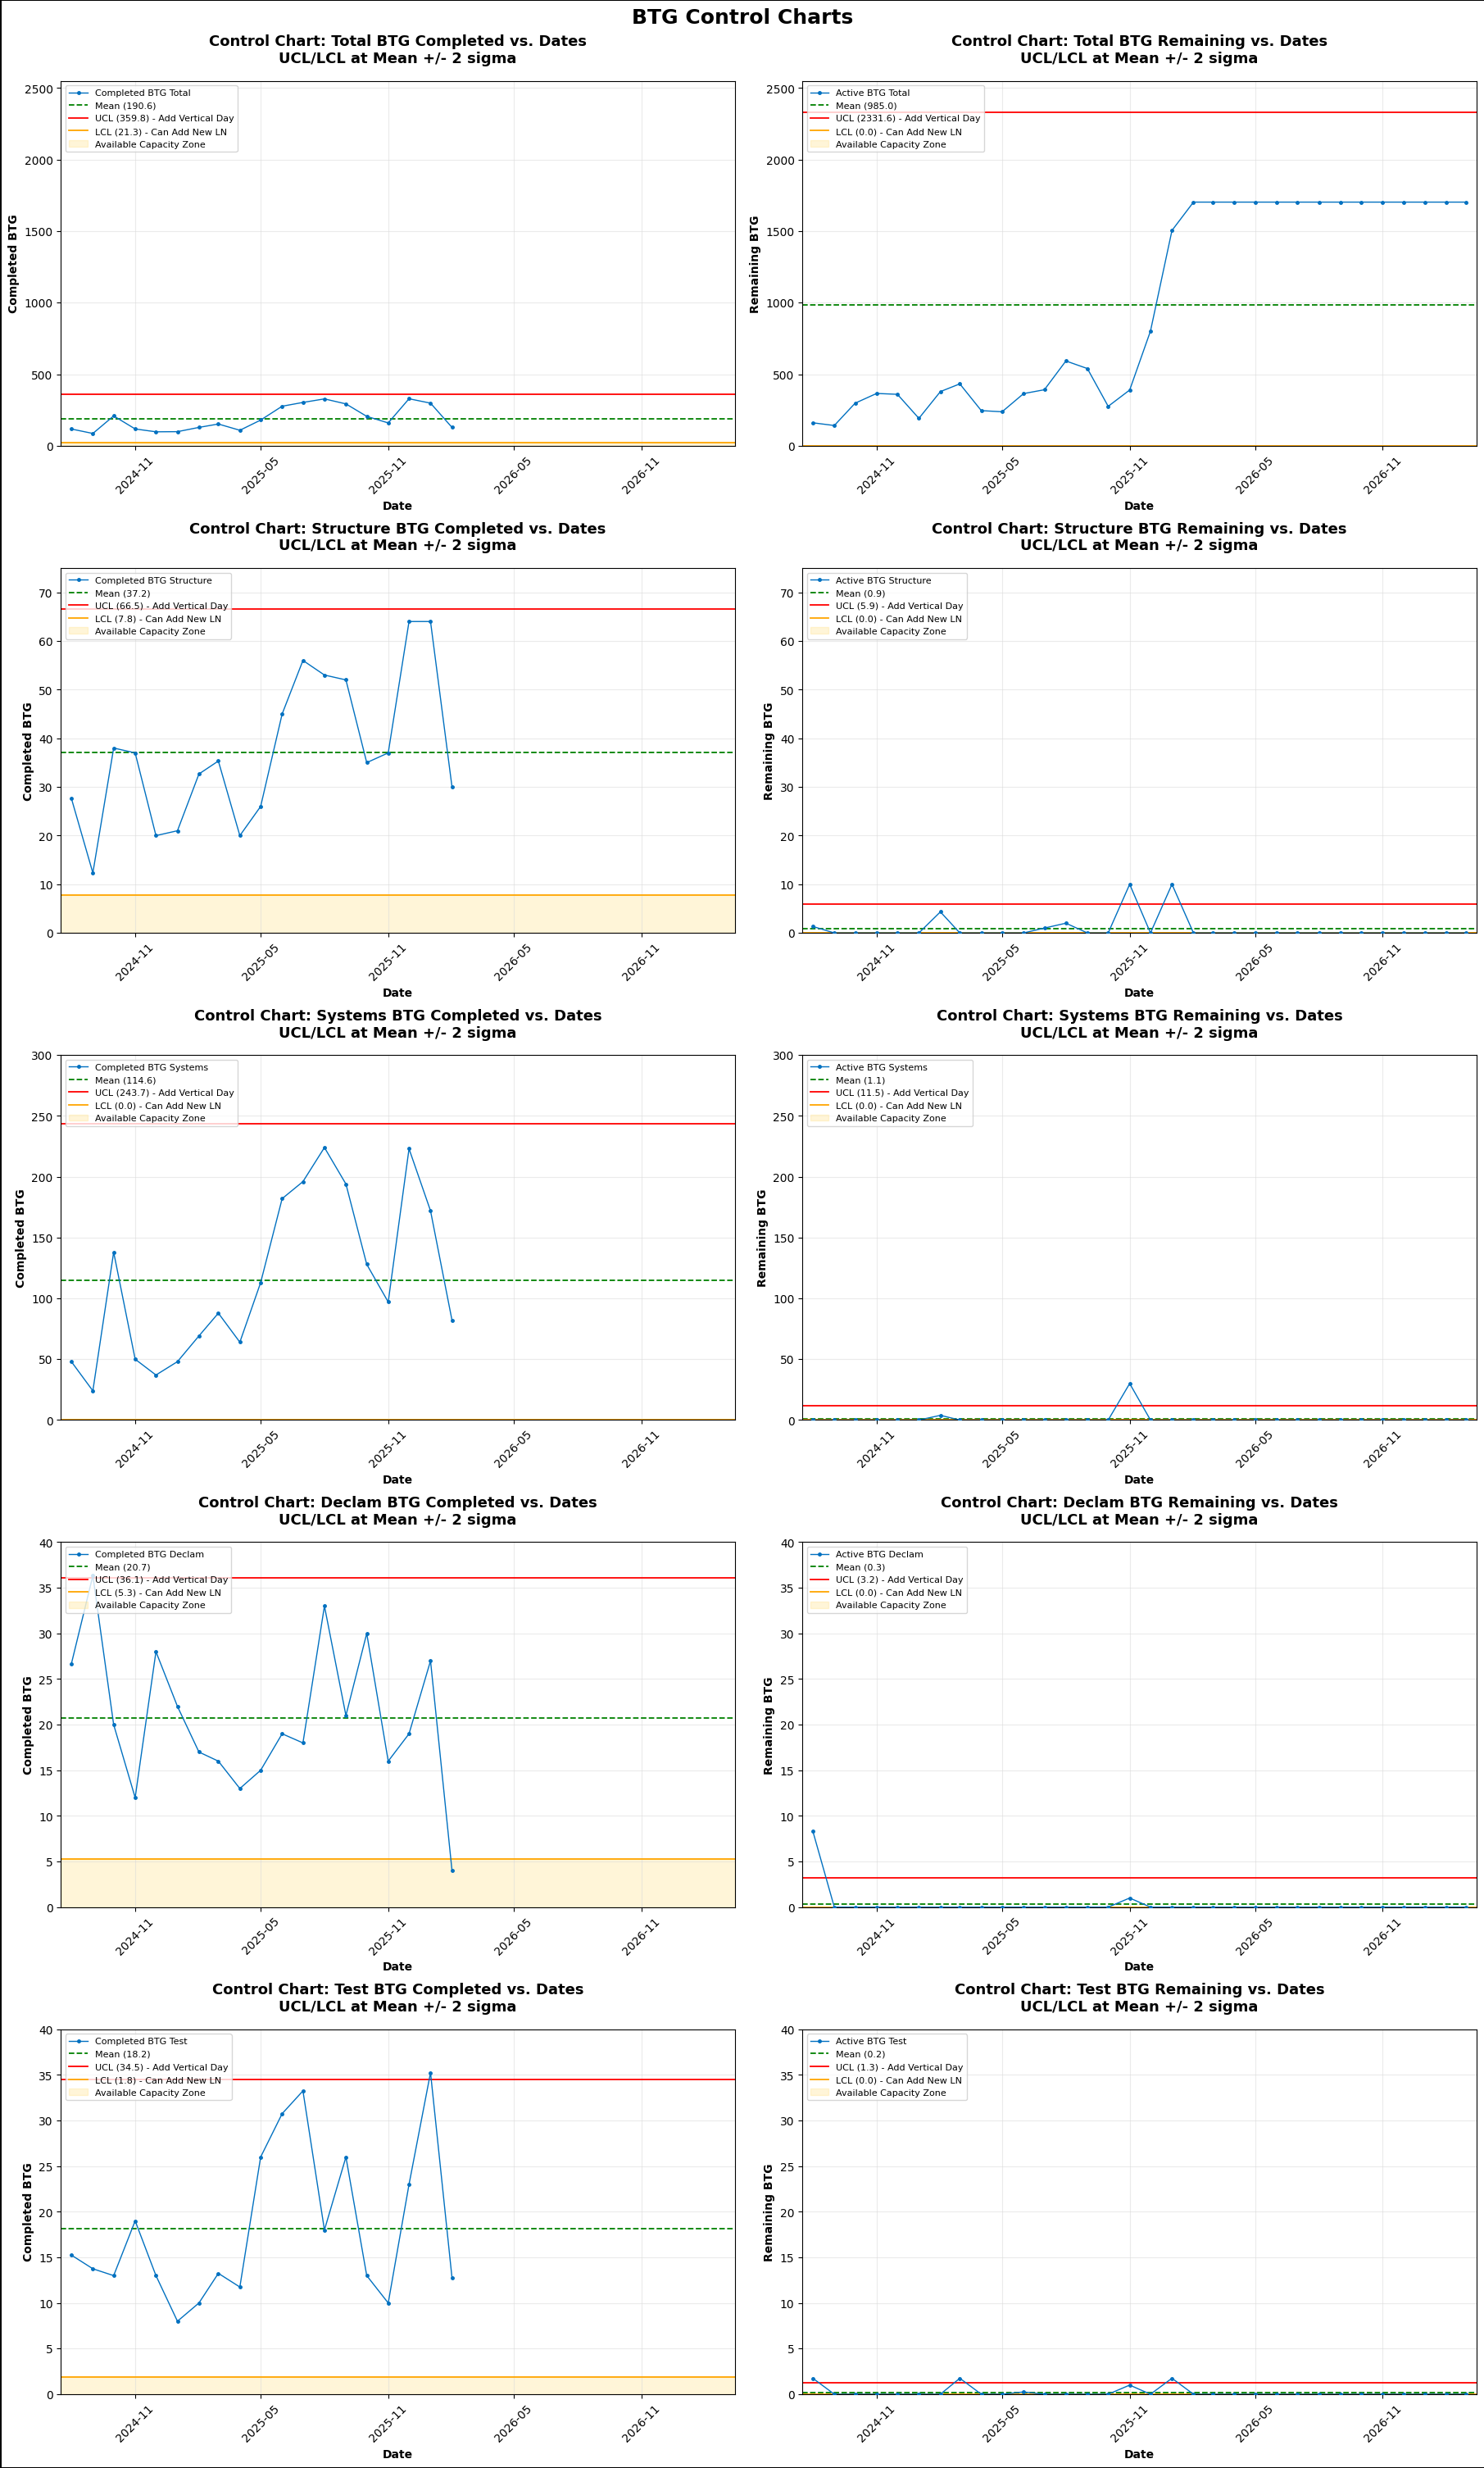

Selected teams: ['total', 'structure', 'systems', 'declam', 'test']
Window months: 36
Explicit month range: start=None, end=None
Saved monthly control charts to /Users/jishnughosh/Documents/GitHub/BSC-FGI_Scheduler/output/monthly_btg_control_charts.png


In [14]:
control_chart()